![ATARRI logos](img/logos.png)

# 2.2 Combining multi-day MONARCH datasets

#### Objective

This notebook aims to provide techniques to combine and concatenate multi-day MONARCH datasets to produce visualisations beyond the 72-hour time period.

## Introduction

Our dust event takes place over five days, so in order to visualise it completely we will need to use several days of MONARCH forecasts. However, because each file is produced daily and covers 72 hours, we have overlapping forecast periods across consecutive files. For example:

- A forecast produced on Day 0 covers from 12:00 on Day 0 to 09:00 on Day 3.
- The forecast produced on Day 1 will begin at 12:00 on Day 1 and cover into Day 4, overlapping with parts of the Day 0 forecast from 00:00 on Day 1 onward.


To avoid redundant analysis and ensure each forecast truly represents future conditions, we should use only the first full forecast day following the model's start time. For a forecast generated on Day 0, this means:

- Select data from 00:00 to 21:00 on Day 1 (i.e., 8 time steps at 3-hour intervals), excluding time steps from Day 0.
- Exclude all time steps prior to 00:00 on Day 1, as they either overlap with past data or reflect time before or during model execution

Let us now look at the following exercises that cover our multi-day dust event. For this, we will load our libraries and also the `functions.ipynb` notebook from our `functions` folder.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import BoundaryNorm

In [3]:
from IPython.utils.io import capture_output
with capture_output():
    %run ../functions/functions1.ipynb

## Example 1: Multi-day forecast average of dust AOD

First, we will create a map average of dust optical spanning the entire dust event.

To load all of our forecast files, we will use `xarray`. With `xr.open_mfdataset`, we can call all `.nc` files inside our target directory and load them all at once. Before they are combined into one dataset, we will set the argument `preprocess=select_timesteps`. The `select_timesteps` function is found in our `functions.ipynb` notebook, and by setting it we can filter for only the timesteps we are interested in. Then, because we want to merge our datasets by aligning each corresponding set of coordinates, we set the parameter `combine='by_coords'`.

In [4]:
ds = xr.open_mfdataset(
    "/shared/data/exp_to_interp/monarch/regional/3hourly/od550_dust/*.nc",
    preprocess=select_timesteps,
    combine='by_coords'
)
ds

<xarray.Dataset> Size: 174MB
Dimensions:     (time: 32, lat: 825, lon: 1650)
Coordinates:
  * time        (time) datetime64[ns] 256B 2025-03-04 ... 2025-03-07T21:00:00
  * lat         (lat) float64 7kB -10.95 -10.85 -10.75 ... 71.25 71.35 71.45
  * lon         (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0
Data variables:
    od550_dust  (time, lat, lon) float32 174MB dask.array<chunksize=(1, 825, 1650), meta=np.ndarray>
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Mon Mar  3 18:03:43 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Tue Mar  4 11:34:48 2025: ncap2 -O -v -s wher...

With our combined datasets, we will now calculate the mean dust optical depth across the entire event.

In [5]:
ds_mean = ds["od550_dust"].max(dim="time")
ds_mean

<xarray.DataArray 'od550_dust' (lat: 825, lon: 1650)> Size: 5MB
dask.array<_nanmax_skip-aggregate, shape=(825, 1650), dtype=float32, chunksize=(825, 1650), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 7kB -10.95 -10.85 -10.75 -10.65 ... 71.25 71.35 71.45
  * lon      (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0

Prior to plotting, we access our coordinates and establish our dust AOD ranges for the colorbar.

In [6]:
lat = ds_mean["lat"]
lon = ds_mean["lon"]

We are also going to extract some time values to use them dynamically in our plot.

In [8]:
time = ds["time"]
first_date = time[0].values
last_date = time[-1].values

In [10]:
first_date

np.datetime64('2025-03-04T00:00:00.000000000')

In [11]:
last_date

np.datetime64('2025-03-07T21:00:00.000000000')

In [12]:
cmap_bdrc = get_cmap_bdrc()
od_norm = get_normalised_bdrc("od550_dust", cmap_bdrc)

Finally, we repeat our coding block with our new variables. From the result, we can observe the impact of the dust event across this entire time period over regions of the Mediterranean, especially over Cyprus and southeastern Spain.

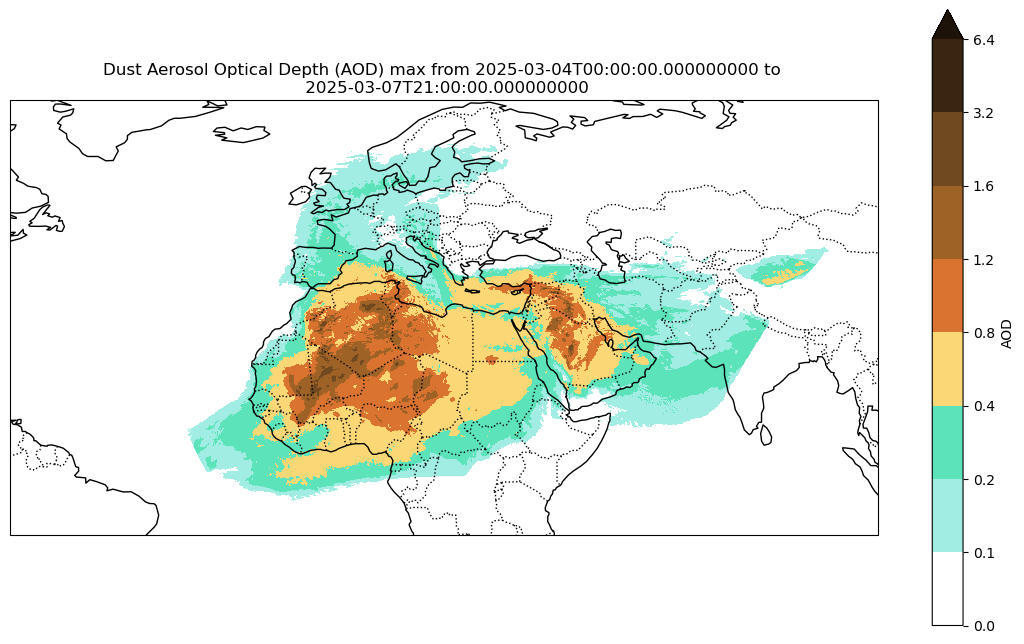

In [14]:
# Create the plot
fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot the data
p = ax.pcolormesh(lon,
                  lat,
                  ds_mean, # add the mean dataset
                  transform=ccrs.PlateCarree(),
                  cmap=cmap_bdrc,
                  norm=od_norm
                 )

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title(f"Dust Aerosol Optical Depth (AOD) max from {first_date} to \n {last_date}")

# Add colorbar
cbar = plt.colorbar(p, ax=ax, orientation="vertical", label="AOD")

# Show the plot
plt.show()

## Example 2: Forecasted AOD exceedance over a threshold

We will now generate an exceedance map for dust optical depth, showing the forecasted possibility that a given AOD threshold is exceeded at each pixel during the dust event. This time, we will also specifically focus on the Mediterranean, so we will subset our plotting region.

First, we will take our merged dataset `ds` and create a slice of `lat` and `lon`.

In [15]:
cropped_ds = ds.sel(lat=slice(25, 45), lon=slice(-15, 40))
cropped_ds

<xarray.Dataset> Size: 14MB
Dimensions:     (time: 32, lat: 200, lon: 550)
Coordinates:
  * time        (time) datetime64[ns] 256B 2025-03-04 ... 2025-03-07T21:00:00
  * lat         (lat) float64 2kB 25.05 25.15 25.25 25.35 ... 44.75 44.85 44.95
  * lon         (lon) float64 4kB -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
Data variables:
    od550_dust  (time, lat, lon) float32 14MB dask.array<chunksize=(1, 200, 550), meta=np.ndarray>
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Mon Mar  3 18:03:43 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Tue Mar  4 11:34:48 2025: ncap2 -O -v -s wher...

Next, we will set our `exceedance` variable. For this, we will set a `threshold` of our interest, and then filter to select all `od550_dust` values above this threshold across the `time` dimension.

In [16]:
threshold = 0.2
exceedance = (cropped_ds["od550_dust"] > threshold).sum(dim="time")
exceedance

<xarray.DataArray 'od550_dust' (lat: 200, lon: 550)> Size: 880kB
dask.array<sum-aggregate, shape=(200, 550), dtype=int64, chunksize=(200, 550), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB 25.05 25.15 25.25 25.35 ... 44.75 44.85 44.95
  * lon      (lon) float64 4kB -14.95 -14.85 -14.75 -14.65 ... 39.75 39.85 39.95

In [17]:
exceedance.values

array([[0, 0, 0, ..., 6, 6, 6],
       [0, 0, 0, ..., 7, 6, 6],
       [0, 0, 0, ..., 9, 6, 6],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(200, 550))

In order to showcase the exceedance in a pixel as a percentage, we need to obtain the number of timesteps available in `ds`. Then, we can divide the number of exceedances by the total timesteps and convert the result to a percentage.

In [18]:
total_timesteps = cropped_ds.dims["time"]
exceedance_rate = (exceedance / total_timesteps) * 100

In [20]:
exceedance_rate.values

array([[ 0.   ,  0.   ,  0.   , ..., 18.75 , 18.75 , 18.75 ],
       [ 0.   ,  0.   ,  0.   , ..., 21.875, 18.75 , 18.75 ],
       [ 0.   ,  0.   ,  0.   , ..., 28.125, 18.75 , 18.75 ],
       ...,
       [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ]],
      shape=(200, 550))

From here, we will repeat our previous plotting steps, setting our custom normalisation ranges for the colorbar.

In [21]:
lat = cropped_ds["lat"]
lon = cropped_ds["lon"]

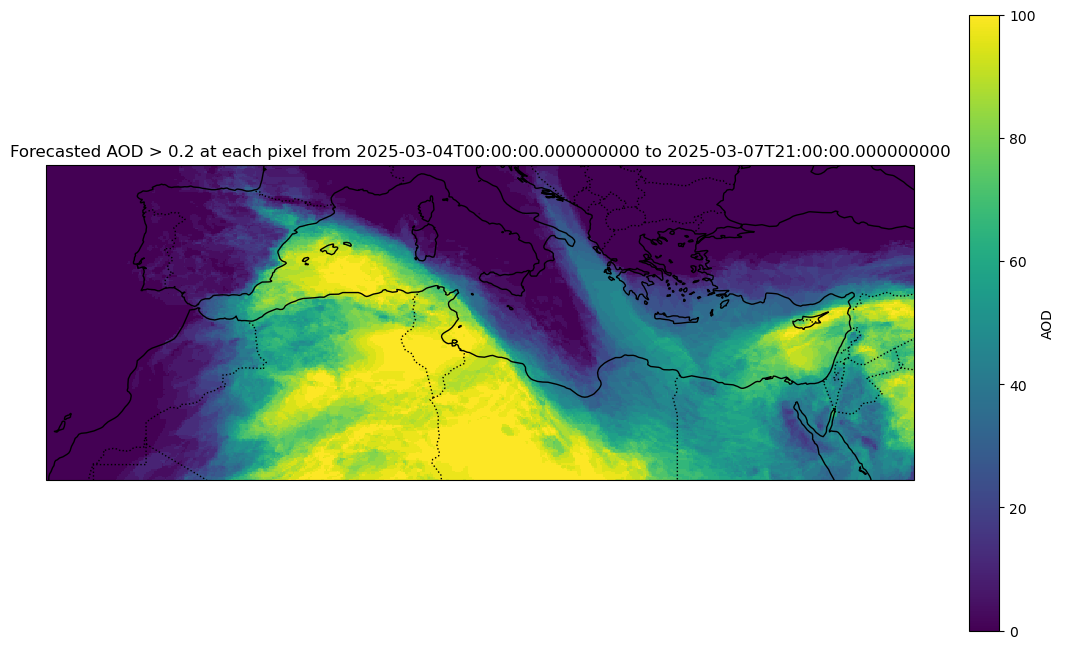

In [22]:
# Create the plot
fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot the data
p = ax.pcolormesh(lon,
                  lat,
                  exceedance_rate, # add the exceedance rate
                  transform=ccrs.PlateCarree(),
                  shading="auto",
                 )

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title(f"Forecasted AOD > {threshold} at each pixel from {first_date} to {last_date}")

# Add colorbar
cbar = plt.colorbar(p, ax=ax, orientation="vertical", label="AOD")

# Show the plot
plt.show()

## References and further reading

- Xarray `.open_mfdataset` [documentation](https://docs.xarray.dev/en/stable/generated/xarray.open_mfdataset.html)
- Xarray `.mean` [documentation](https://docs.xarray.dev/en/latest/generated/xarray.DataArray.mean.html)
- Matplotlib `.pyplot.pcolormesh` [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html)

<table style="width:100%;">
    <tr>
        <td style="text-align: center;"><a href="VT2-1-visualising_MONARCH.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT2-3-interactive_plotting.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr
</table>